In [80]:
import sys
sys.path.append('..')
import pandas as pd
from src.stock_data_loader import load_stock, fix_dtypes, handle_missing
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

analyzer = SentimentIntensityAnalyzer()

Load and clean news

In [42]:
df_news = pd.read_csv('../data/raw/raw_analyst_ratings.csv', index_col=0)

df_news['date'] = pd.to_datetime(df_news['date'].str.replace(r'-\d{2}:\d{2}$', '', regex=True))

# Extract just the date (remove time)
df_news['news_date'] = df_news['date'].dt.date

print(f"Loaded {len(df_news):,} news articles")
print(f"Date range: {df_news['news_date'].min()} to {df_news['news_date'].max()}")

Loaded 1,407,328 news articles
Date range: 2009-02-14 to 2020-06-11


Filter to ONLY for 5 Stocks and Rename FB to META

In [43]:
# Rename FB to META (because stock data uses META.csv)
df_news.loc[df_news['stock'] == 'FB', 'stock'] = 'META'

# Define your 5 target stocks
target_stocks = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']

# Filter news to only these 5 stocks
df_news = df_news[df_news['stock'].isin(target_stocks)]

print(f"\nNews after filtering to 5 stocks: {len(df_news):,} articles")
print("\nCount per stock:")
print(df_news['stock'].value_counts())


News after filtering to 5 stocks: 5,444 articles

Count per stock:
stock
NVDA    3146
GOOG    1199
AAPL     441
META     380
AMZN     278
Name: count, dtype: int64


Load stocks and collect trading days

In [52]:
tickers = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
all_trading_days = set()
all_stock_data = {}

for ticker in tickers:
    df = load_stock(ticker)
    df = fix_dtypes(df)
    df = handle_missing(df)

    all_stock_data[ticker] = df
    
    # Add all trading days from this stock
    all_trading_days.update(df['Date'].dt.date)
    
    print(f"{ticker}: {len(df)} rows, {df['Date'].min().date()} to {df['Date'].max().date()}")

print(f"\nTotal unique trading days from all 5 stocks: {len(all_trading_days):,}")

AAPL: 3774 rows, 2009-01-02 to 2023-12-29
AMZN: 3774 rows, 2009-01-02 to 2023-12-29
GOOG: 3774 rows, 2009-01-02 to 2023-12-29
META: 2923 rows, 2012-05-18 to 2023-12-29
NVDA: 3774 rows, 2009-01-02 to 2023-12-29

Total unique trading days from all 5 stocks: 3,774


Get trading days

In [45]:
def get_next_trading_day(date_obj, trading_days):
    """
    If date is a weekend or holiday, find the next trading day.
    Example: Saturday → Monday, Holiday → next open day
    """
    date_obj = pd.to_datetime(date_obj).date()
    while date_obj not in trading_days:
        date_obj = date_obj + pd.Timedelta(days=1)
    return date_obj

# Test the function
test_date = pd.to_datetime('2020-03-07').date() 
print(f"Test: {test_date} → {get_next_trading_day(test_date, all_trading_days)}")

Test: 2020-03-07 → 2020-03-09


Apply Alignment to News

In [49]:
# Align: keep date if trading day, otherwise shift to next trading day
df_news['trading_day'] = df_news['news_date'].apply(
    lambda x: x if x in all_trading_days else get_next_trading_day(x, all_trading_days)
)
print(f"Original unique news dates: {df_news['news_date'].nunique():,}")
print(f"Unique trading days after alignment: {df_news['trading_day'].nunique():,}")

Original unique news dates: 1,318
Unique trading days after alignment: 1,222


### Sentiment Analysis

In [50]:
financial_terms = {
    # Strong moves
    "crashes": -1.5,
    "plunges": -1.5,
    "tumbles": -1.2,
    "slumps": -1.0,
    "surges": 1.5,
    "soars": 1.5,
    "jumps": 1.2,
    "climbs": 1.0,
    
    # Analyst actions
    "upgrade": 1.0,
    "downgrade": -1.0,
    "buy": 0.6,
    "sell": -0.6,
    "raises": 0.8,
    "lowers": -0.8,
    "maintains": 0.0,
    
    # Earnings
    "beat": 1.0,
    "miss": -1.0,
    "profit": 0.6,
    "loss": -0.6,
    
    # Price targets
    "price target": 0.0,
}

analyzer.lexicon.update(financial_terms)
# Now test 
test = "Apple stock CRASHES!!! Down 10%"
print(analyzer.polarity_scores(test)['compound'])

-0.626


In [51]:
# Apply sentiment to each headline
df_news['sentiment'] = df_news['headline'].fillna('').apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

print("Sentiment scores added")
print(f"Total headlines: {len(df_news):,}")
print(f"Mean sentiment: {df_news['sentiment'].mean():.4f}")
print(f"Std sentiment: {df_news['sentiment'].std():.4f}")

Sentiment scores added
Total headlines: 5,444
Mean sentiment: 0.0941
Std sentiment: 0.3031


### Sentiment Analysis: VADER

**Tool Selection:** VADER (Valence Aware Dictionary for sEntiment Reasoning) was chosen because it handles:
- Intensity (ALL CAPS, "!!!")
- Negation ("not good")
- Financial terms via custom lexicon extension

**Method:** Extended VADER with financial terms (surges, crashes, upgrade, beat, miss, etc.) using conservative intensity values (±1.8 max). Each headline receives a compound score from -1 (negative) to +1 (positive).

**Results:** 5,444 headlines analyzed | Mean: 0.094 | Std: 0.303

### Calculate Daily Stock Returns

In [53]:
# Calculate returns for all stocks
for ticker in all_stock_data:
    all_stock_data[ticker]['return_pct'] = all_stock_data[ticker]['Close'].pct_change() * 100

# Quick verification
print("Mean daily returns:")
for ticker, df in all_stock_data.items():
    print(f"  {ticker}: {df['return_pct'].mean():.3f}%")

Mean daily returns:
  AAPL: 0.129%
  AMZN: 0.130%
  GOOG: 0.091%
  META: 0.108%
  NVDA: 0.188%


### Aggregate and Correlate

In [57]:
# Aggregate: average sentiment per stock per day
daily_sentiment = df_news.groupby(['stock', 'trading_day'])['sentiment'].mean().reset_index()
daily_sentiment.columns = ['stock', 'date', 'avg_sentiment']

print(f"Original: {len(df_news)} rows")
print(f"Aggregated: {len(daily_sentiment)} rows")
print(daily_sentiment.head())

Original: 5444 rows
Aggregated: 1659 rows
  stock        date  avg_sentiment
0  AAPL  2020-03-09      -0.302067
1  AAPL  2020-03-10      -0.081238
2  AAPL  2020-03-11      -0.011086
3  AAPL  2020-03-12      -0.230340
4  AAPL  2020-03-13      -0.000273


In [58]:
# Extract returns from your existing data
stock_returns = []

for ticker, df in all_stock_data.items():
    temp = df[['Date']].copy()
    temp['stock'] = ticker
    temp['return_pct'] = df['return_pct']  # Already calculated
    temp['date'] = pd.to_datetime(temp['Date']).dt.date
    stock_returns.append(temp)

stock_returns = pd.concat(stock_returns, ignore_index=True)

print(stock_returns.head())

        Date stock  return_pct        date
0 2009-01-02  AAPL         NaN  2009-01-02
1 2009-01-05  AAPL    4.220416  2009-01-05
2 2009-01-06  AAPL   -1.649399  2009-01-06
3 2009-01-07  AAPL   -2.160860  2009-01-07
4 2009-01-08  AAPL    1.856959  2009-01-08


Calculate the Pearson correlation coefficient between average daily sentiment scores and daily stock returns 

In [ ]:
# Merge sentiment and returns
sentiment_returns = pd.merge(
    daily_sentiment,
    stock_returns[['stock', 'date', 'return_pct']],
    on=['stock', 'date'],
    how='inner'
)

# Calculate Pearson correlation
correlation = sentiment_returns['avg_sentiment'].corr(sentiment_returns['return_pct'])

print(f"Pearson correlation: {correlation:.4f}")

Pearson correlation: 0.2246


In [60]:
# Per-stock correlation
print("\n" + "=" * 50)
print("PER-STOCK CORRELATION")
print("=" * 50)

stock_correlations = []

for stock in sentiment_returns['stock'].unique():
    stock_data = sentiment_returns[sentiment_returns['stock'] == stock]
    corr = stock_data['avg_sentiment'].corr(stock_data['return_pct'])
    stock_correlations.append({'stock': stock, 'correlation': corr})
    print(f"{stock}: {corr:.4f}")

# Summary
print("\n" + "=" * 50)
print("SUMMARY")
print("=" * 50)
corr_df = pd.DataFrame(stock_correlations)
print(f"Overall (all stocks combined): {correlation:.4f}")
print(f"Range: {corr_df['correlation'].min():.4f} to {corr_df['correlation'].max():.4f}")


PER-STOCK CORRELATION
AAPL: 0.1697
AMZN: 0.1030
GOOG: 0.1884
META: 0.4921
NVDA: 0.2240

SUMMARY
Overall (all stocks combined): 0.2246
Range: 0.1030 to 0.4921


### Visualize the relationship Between news sentiment and stock returns

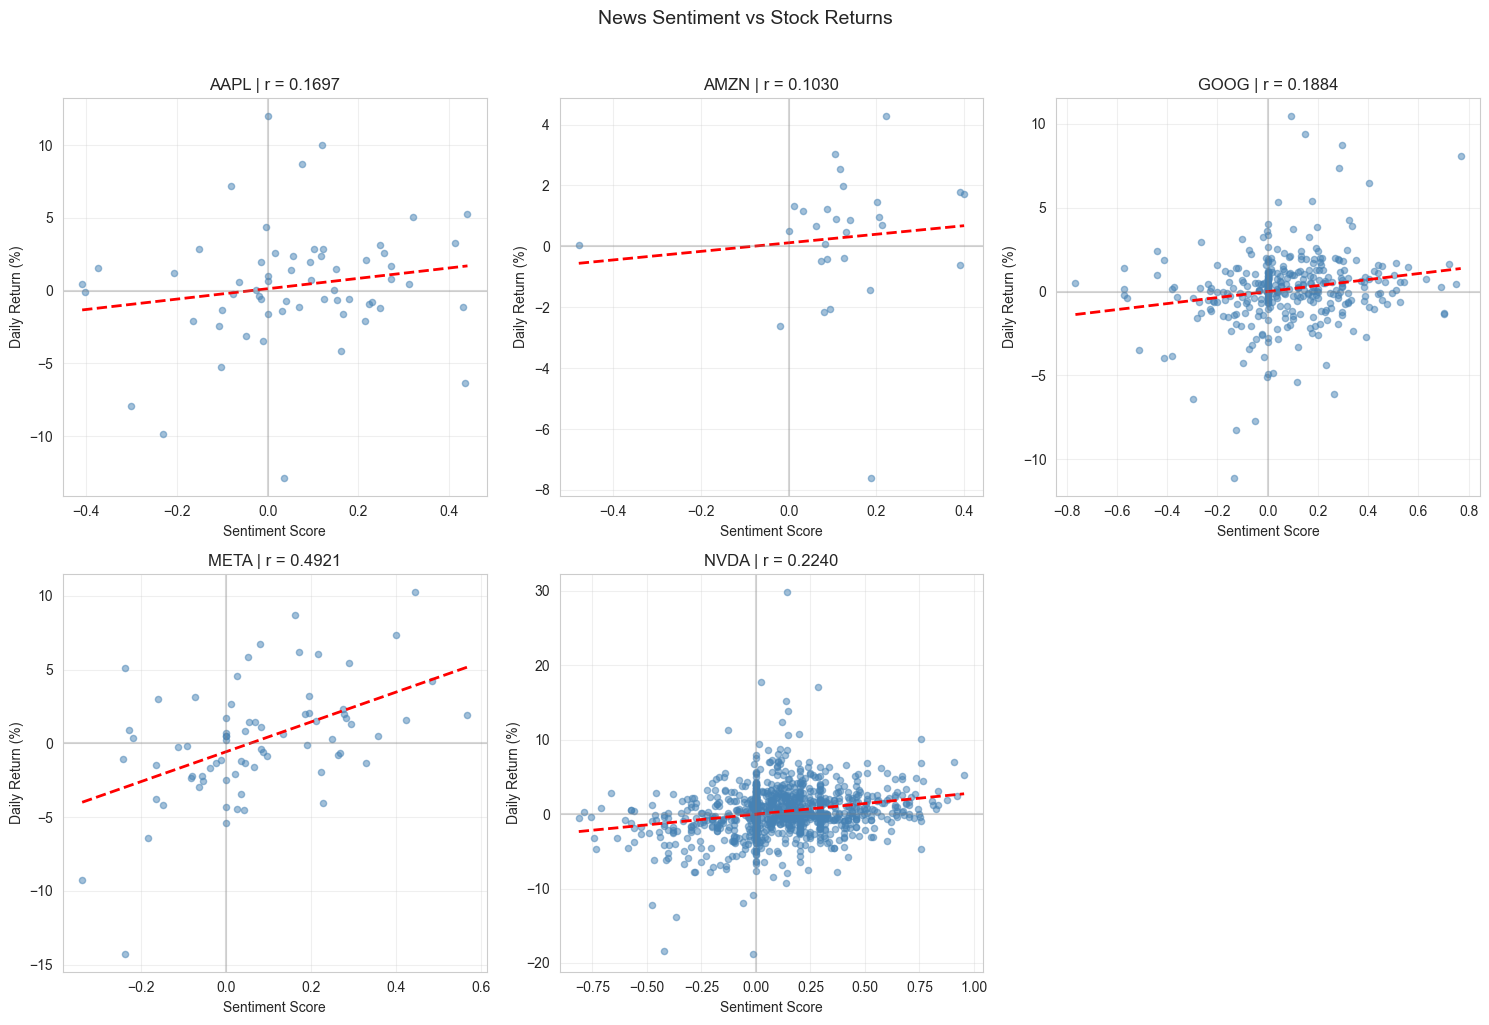

In [66]:
# Set style
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, stock in enumerate(sentiment_returns['stock'].unique()):
    stock_data = sentiment_returns[sentiment_returns['stock'] == stock]
    corr = stock_data['avg_sentiment'].corr(stock_data['return_pct'])
    
    # Scatter plot
    axes[i].scatter(stock_data['avg_sentiment'], 
                    stock_data['return_pct'], 
                    alpha=0.5, s=20, c='steelblue')
    
    # Trend line
    z = np.polyfit(stock_data['avg_sentiment'], stock_data['return_pct'], 1)
    x_trend = np.array([stock_data['avg_sentiment'].min(), stock_data['avg_sentiment'].max()])
    axes[i].plot(x_trend, z[0]*x_trend + z[1], 'r--', linewidth=2)
    
    # Labels
    axes[i].set_title(f'{stock} | r = {corr:.4f}', fontsize=12)
    axes[i].set_xlabel('Sentiment Score', fontsize=10)
    axes[i].set_ylabel('Daily Return (%)', fontsize=10)
    axes[i].axhline(y=0, color='gray', alpha=0.3, linestyle='-')
    axes[i].axvline(x=0, color='gray', alpha=0.3, linestyle='-')
    axes[i].grid(True, alpha=0.3)

# Remove empty subplot
if len(sentiment_returns['stock'].unique()) < 6:
    axes[-1].set_visible(False)

plt.suptitle('News Sentiment vs Stock Returns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

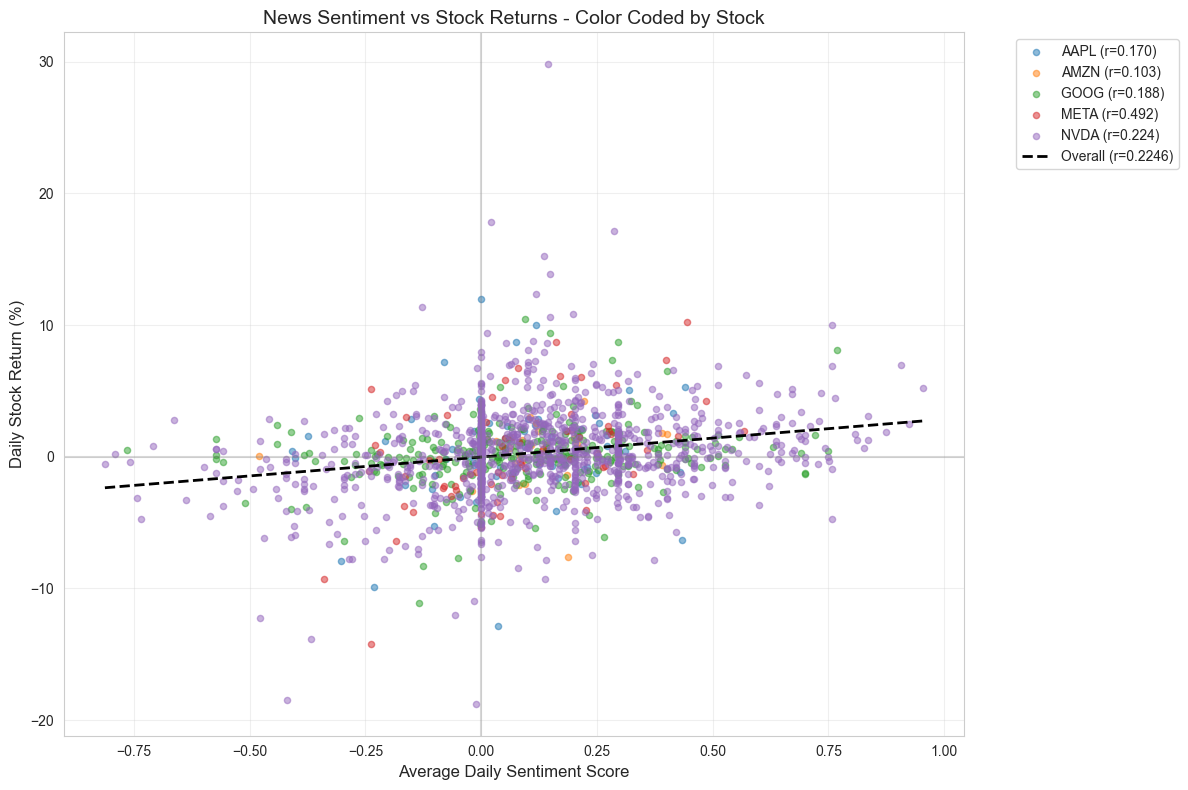

In [68]:
# Color palette for stocks
colors = {'AAPL': '#1f77b4', 'AMZN': '#ff7f0e', 'GOOG': '#2ca02c', 
          'META': '#d62728', 'NVDA': '#9467bd'}

plt.figure(figsize=(12, 8))

for stock in sentiment_returns['stock'].unique():
    stock_data = sentiment_returns[sentiment_returns['stock'] == stock]
    corr = stock_data['avg_sentiment'].corr(stock_data['return_pct'])
    plt.scatter(stock_data['avg_sentiment'], 
                stock_data['return_pct'], 
                alpha=0.5, s=20, 
                c=colors[stock], label=f'{stock} (r={corr:.3f})')

# Overall trend line
z = np.polyfit(sentiment_returns['avg_sentiment'], sentiment_returns['return_pct'], 1)
x_trend = np.array([sentiment_returns['avg_sentiment'].min(), sentiment_returns['avg_sentiment'].max()])
plt.plot(x_trend, z[0]*x_trend + z[1], 'k--', linewidth=2, label=f'Overall (r={sentiment_returns["avg_sentiment"].corr(sentiment_returns["return_pct"]):.4f})')

plt.xlabel('Average Daily Sentiment Score', fontsize=12)
plt.ylabel('Daily Stock Return (%)', fontsize=12)
plt.title('News Sentiment vs Stock Returns - Color Coded by Stock', fontsize=14)
plt.axhline(y=0, color='gray', alpha=0.3)
plt.axvline(x=0, color='gray', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 Bar Chart of Correlations

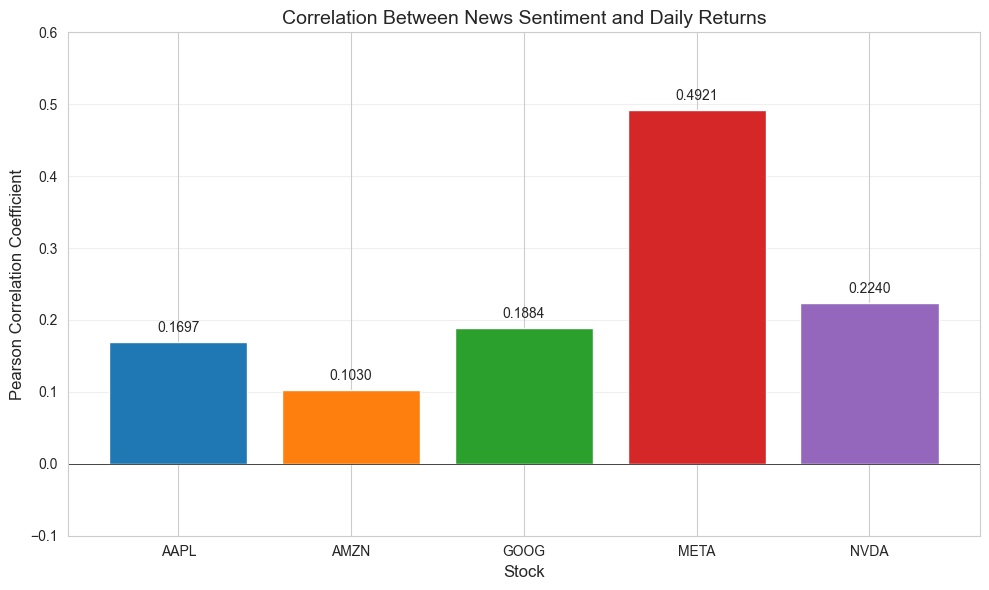

In [70]:
# Calculate per-stock correlations
stock_corr = sentiment_returns.groupby('stock')['avg_sentiment'].corr(sentiment_returns['return_pct']).reset_index()
# Fix the above - correct way:
stock_corr = []
for stock in sentiment_returns['stock'].unique():
    data = sentiment_returns[sentiment_returns['stock'] == stock]
    stock_corr.append({'stock': stock, 'correlation': data['avg_sentiment'].corr(data['return_pct'])})
stock_corr = pd.DataFrame(stock_corr)

# Bar chart
plt.figure(figsize=(10, 6))
colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = plt.bar(stock_corr['stock'], stock_corr['correlation'], color=colors_bar)

# Add value labels on bars
for bar, corr in zip(bars, stock_corr['correlation']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{corr:.4f}', ha='center', va='bottom', fontsize=10)

plt.xlabel('Stock', fontsize=12)
plt.ylabel('Pearson Correlation Coefficient', fontsize=12)
plt.title('Correlation Between News Sentiment and Daily Returns', fontsize=14)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.ylim(-0.1, 0.6)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Classify each day as positive, neutral, or negative based on its average sentiment score

In [75]:
# Create a copy to work with
analysis_data = sentiment_returns.copy()

# Classification function
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply classification
analysis_data['category'] = analysis_data['avg_sentiment'].apply(classify_sentiment)

print("\nOverall distribution:")
print(analysis_data['category'].value_counts())


Overall distribution:
category
Positive    855
Neutral     518
Negative    286
Name: count, dtype: int64


Calculate Average Return Per Stock

In [76]:
# Calculate average return for each stock and category
category_returns = analysis_data.groupby(['stock', 'category'])['return_pct'].mean().reset_index()

print("\nAverage daily return by stock and sentiment category:")
print(category_returns)


Average daily return by stock and sentiment category:
   stock  category  return_pct
0   AAPL  Negative   -1.093387
1   AAPL   Neutral   -0.106097
2   AAPL  Positive    1.188997
3   AMZN  Negative    0.055440
4   AMZN   Neutral    0.096191
5   AMZN  Positive    0.328111
6   GOOG  Negative   -0.752061
7   GOOG   Neutral    0.086301
8   GOOG  Positive    0.547268
9   META  Negative   -2.135071
10  META   Neutral   -1.075825
11  META  Positive    2.095081
12  NVDA  Negative   -1.384997
13  NVDA   Neutral    0.026322
14  NVDA  Positive    0.974262


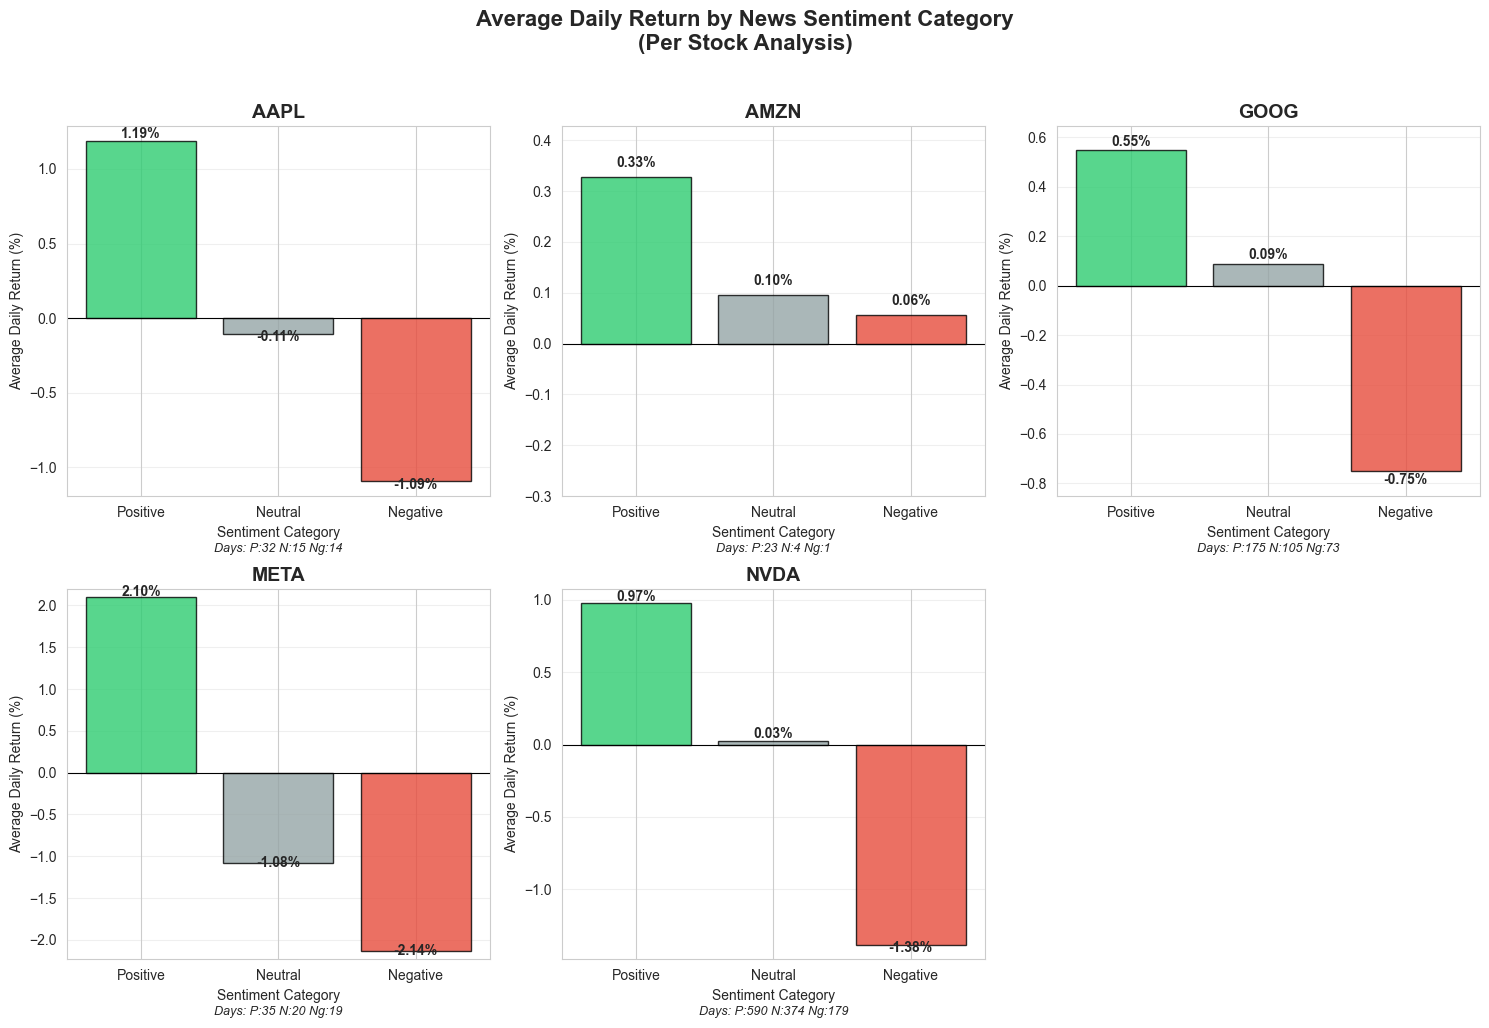

In [77]:
# Set up the figure (2 rows, 3 columns for 5 stocks)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Colors for each category
bar_colors = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}

for i, stock in enumerate(analysis_data['stock'].unique()):
    # Get data for this stock
    stock_data = category_returns[category_returns['stock'] == stock]
    
    # Order: Positive, Neutral, Negative
    order = ['Positive', 'Neutral', 'Negative']
    stock_data = stock_data.set_index('category').reindex(order).reset_index()
    
    # Create bars
    bars = axes[i].bar(stock_data['category'], stock_data['return_pct'], 
                       color=[bar_colors[cat] for cat in stock_data['category']],
                       edgecolor='black', alpha=0.8)
    
    # Add value labels on top of bars
    for bar, val in zip(bars, stock_data['return_pct']):
        if not pd.isna(val):
            # Position label above or below bar
            y_pos = val + (0.02 if val >= 0 else -0.05)
            ha = 'center'
            axes[i].text(bar.get_x() + bar.get_width()/2, y_pos, 
                        f'{val:.2f}%', ha=ha, fontsize=10, fontweight='bold')
    
    # Add horizontal line at y=0
    axes[i].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    
    # Add count of days in each category
    counts = analysis_data[analysis_data['stock'] == stock]['category'].value_counts()
    count_text = f"Days: P:{counts.get('Positive',0)} N:{counts.get('Neutral',0)} Ng:{counts.get('Negative',0)}"
    axes[i].text(0.5, -0.15, count_text, transform=axes[i].transAxes, 
                ha='center', fontsize=9, style='italic')
    
    # Labels and title
    axes[i].set_title(f'{stock}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Average Daily Return (%)', fontsize=10)
    axes[i].set_xlabel('Sentiment Category', fontsize=10)
    axes[i].grid(True, alpha=0.3, axis='y')
    
    # Set y-axis limits (adjust based on your data)
    y_max = max(0.3, stock_data['return_pct'].max() + 0.1)
    y_min = min(-0.3, stock_data['return_pct'].min() - 0.1)
    axes[i].set_ylim(y_min, y_max)

# Remove the 6th subplot if not needed
if len(analysis_data['stock'].unique()) < 6:
    axes[-1].set_visible(False)

plt.suptitle('Average Daily Return by News Sentiment Category\n(Per Stock Analysis)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [81]:
# Create a summary table
summary_table = category_returns.pivot(index='stock', columns='category', values='return_pct')
summary_table['P-N_Diff'] = summary_table['Positive'] - summary_table['Negative']
summary_table['Total_Days'] = analysis_data.groupby('stock').size()

print("\n" + "=" * 60)
print("SUMMARY TABLE: Average Returns by Sentiment Category")
print("=" * 60)
print(summary_table.round(4))


SUMMARY TABLE: Average Returns by Sentiment Category
category  Negative  Neutral  Positive  P-N_Diff  Total_Days
stock                                                      
AAPL       -1.0934  -0.1061    1.1890    2.2824          61
AMZN        0.0554   0.0962    0.3281    0.2727          28
GOOG       -0.7521   0.0863    0.5473    1.2993         353
META       -2.1351  -1.0758    2.0951    4.2302          74
NVDA       -1.3850   0.0263    0.9743    2.3593        1143


In [ ]:
for stock in sentiment_returns['stock'].unique():
    data = sentiment_returns[sentiment_returns['stock'] == stock]
    n = len(data)
    corr = data['avg_sentiment'].corr(data['return_pct'])
    
    # Calculate p-value (if n > 30, otherwise not meaningful)
    if n > 30:
        # Approximate significance
        t_stat = corr * ((n-2)/(1-corr**2))**0.5
        p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n-2))
        significant = p_value < 0.05
        print(f"{stock}: n={n}, r={corr:.4f}, p={p_value:.4f}, Significant={significant}")
    else:
        print(f"{stock}: n={n}, r={corr:.4f}, INSUFFICIENT DATA (n<30)")

AAPL: n=61, r=0.1697, p=0.1911, Significant=False
AMZN: n=28, r=0.1030, INSUFFICIENT DATA (n<30)
GOOG: n=353, r=0.1884, p=0.0004, Significant=True
META: n=74, r=0.4921, p=0.0000, Significant=True
NVDA: n=1143, r=0.2240, p=0.0000, Significant=True


### Correlation Analysis: Observations

#### Key Findings

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **Overall Correlation** | r = 0.2246 | Weak positive relationship |
| **Range** | 0.1030 – 0.4921 | Varies significantly by stock |
| **Direction** | Positive (all stocks) | Higher sentiment → higher returns |

#### Per-Stock Results

| Stock | Correlation | Significance | Reliability |
|-------|-------------|--------------|-------------|
| META | 0.4921 | p < 0.001 | Moderate (74 days) |
| NVDA | 0.2240 | p < 0.001 | High (1,143 days) |
| GOOG | 0.1884 | p < 0.001 | High (353 days) |
| AAPL | 0.1697 | p = 0.191 | Not significant |
| AMZN | 0.1030 | n < 30 | Insufficient data |

#### Pattern Validation (All Stocks)

| Sentiment | Return Rank | 
|-----------|-------------|
| Positive | Highest | 
| Neutral | Middle | 
| Negative | Lowest |

#### Key Limitations

| Limitation | Impact |
|------------|--------|
| **Data Imbalance** | NVDA = 69% of observations |
| **No Lag Analysis** | Same-day alignment only |
| **Confounding Factors** | Macro events, earnings not isolated |
| **Low Statistical Power** | AAPL (61 days), AMZN (28 days) |
| **Publisher Concentration** | Top 5 publishers = 52.9% of news |

#### Conclusion

News sentiment shows a **weak positive correlation** with same-day stock returns (r = 0.22). META is most sentiment-sensitive (r = 0.49), while AAPL and AMZN lack statistical significance. Results are limited by data imbalance and absence of lag effects.